<a href="https://colab.research.google.com/github/GreeshmaDS/weather-data-analysis/blob/main/Weather_data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
latitude = 12.5844
longitude = 77.3530

print("Fetching weather data for Bangalore from Open-Meteo API...")
url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&hourly=temperature_2m,relative_humidity_2m,pressure_msl,windspeed_10m&timezone=auto&past_days=60&forecast_days=1"

response = requests.get(url)
data = response.json()

Fetching weather data for Bangalore from Open-Meteo API...


In [ ]:
# Convert to DataFrame
df = pd.DataFrame({
    'DateTime': pd.to_datetime(data['hourly']['time']),
    'Temperature': data['hourly']['temperature_2m'],
    'Humidity': data['hourly']['relative_humidity_2m'],
    'Pressure': data['hourly']['pressure_msl'],
    'WindSpeed': data['hourly']['windspeed_10m']
})
#Preprocess Data
df['Date'] = df['DateTime'].dt.date
daily_df = df.groupby('Date').agg({
    'Temperature': 'mean',
    'Humidity': 'mean',
    'Pressure': 'mean',
    'WindSpeed': 'mean'
}).reset_index()
daily_df = daily_df.sort_values('Date')

In [ ]:
# Create previous day (lag) features
daily_df['Prev_Temp'] = daily_df['Temperature'].shift(1)
daily_df['Prev_Humidity'] = daily_df['Humidity'].shift(1)
daily_df['Prev_WindSpeed'] = daily_df['WindSpeed'].shift(1)
daily_df['Prev_Pressure'] = daily_df['Pressure'].shift(1)
daily_df = daily_df.dropna()

In [ ]:
# Extract date components
daily_df['Year'] = pd.to_datetime(daily_df['Date']).dt.year
daily_df['Month'] = pd.to_datetime(daily_df['Date']).dt.month
daily_df['Day'] = pd.to_datetime(daily_df['Date']).dt.day
#Save Cleaned Data to CSV
daily_df.to_csv('weather_data_bangalore.csv', index=False)
print("Weather data saved as 'weather_data_bangalore.csv'")

Weather data saved as 'weather_data_bangalore.csv'


In [ ]:
#Train Model
X = daily_df[['Prev_Temp', 'Prev_Humidity', 'Prev_WindSpeed', 'Prev_Pressure', 'Month', 'Day']]
y = daily_df['Temperature']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
#Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")

Model Evaluation Metrics:
MAE  : 0.66
MSE  : 0.89
RMSE : 0.94
R²   : 0.61


In [ ]:
#Predict Next Day’s Temperature
latest = daily_df.iloc[-1]
input_data = [[
    latest['Temperature'],
    latest['Humidity'],
    latest['WindSpeed'],
    latest['Pressure'],
    latest['Month'],
    latest['Day']
]]

predicted_temp = model.predict(input_data)[0]
print(f"Predicted Temperature for Next Day in Bangalore: {predicted_temp:.2f} °C")

Predicted Temperature for Next Day in Bangalore: 29.10 °C


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Saved graph as 'temp_graph.png'


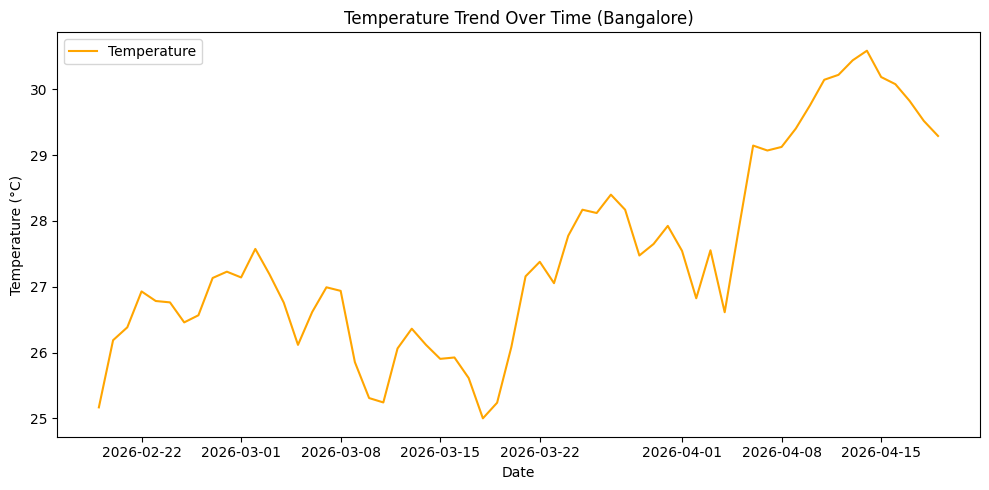

In [ ]:
#Visualization (All Figures Visible Together)
# --- Figure 1: Temperature Trend ---
plt.figure(1, figsize=(10,5))
plt.plot(daily_df['Date'], daily_df['Temperature'], label='Temperature', color='orange')
plt.title('Temperature Trend Over Time (Bangalore)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.savefig('temp_graph.png')
print("Saved graph as 'temp_graph.png'")


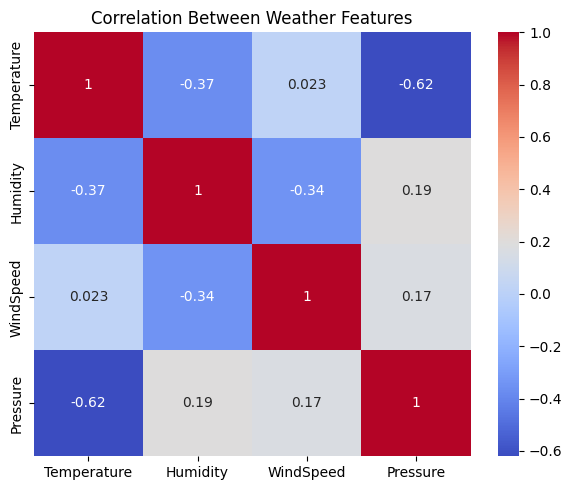

In [ ]:
# --- Figure 2: Correlation Heatmap ---
plt.figure(2, figsize=(6,5))
sns.heatmap(daily_df[['Temperature', 'Humidity', 'WindSpeed', 'Pressure']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Between Weather Features')
plt.tight_layout()


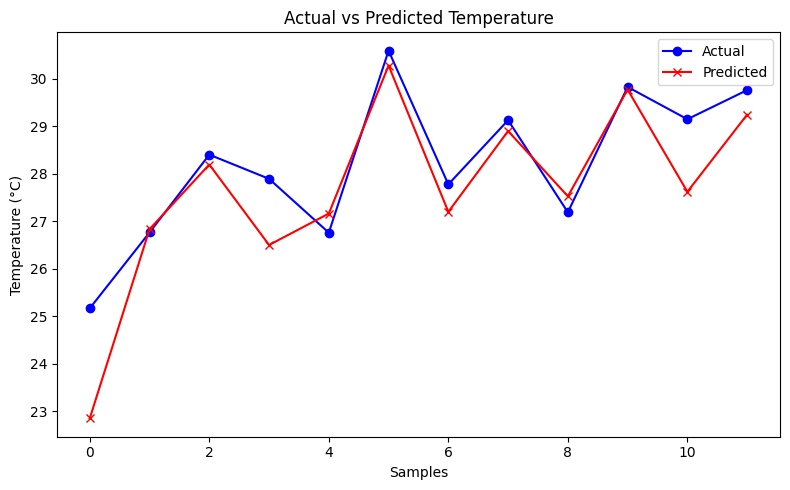

In [ ]:
# --- Figure 3: Actual vs Predicted ---
plt.figure(3, figsize=(8,5))
plt.plot(y_test.values, label='Actual', color='blue', marker='o')
plt.plot(y_pred, label='Predicted', color='red', marker='x')
plt.title('Actual vs Predicted Temperature')
plt.xlabel('Samples')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()

plt.show()